# Transport through an arbitrary finite (0d) central region

`Hamiltonian.get_central_heterostructure(i, j, left=..., right=...)` lets *any* finite (0d)
Hamiltonian act as the scattering region, contacted by two semi-infinite 1D chain leads attached
at sites $i$ and $j$ -- unlike the previous notebooks, where the central region (if any) was
built out of copies of the leads' own unit cell. Below, a short 5-site chain segment is contacted
by a normal lead on one end and an s-wave superconducting lead on the other, giving the same
Andreev-conductance physics as the direct N-S junction but through a genuinely finite, separately
defined central object.

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import heterostructures

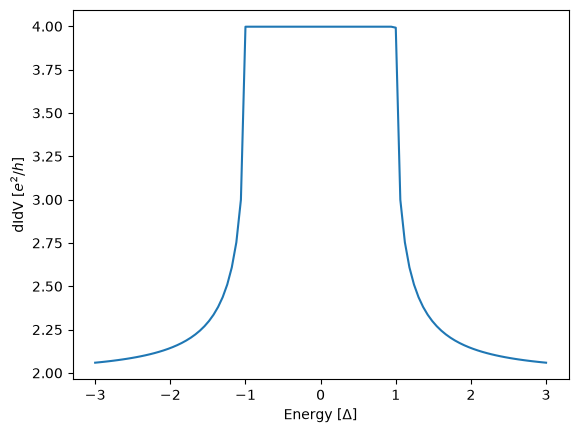

In [2]:
g = geometry.chain()
gc = g.get_supercell(5)
gc.dimensionality = 0 # a finite, 5-site cluster -- no periodicity
hc = gc.get_hamiltonian() # the central region -- can be any 0d Hamiltonian

h_normal = g.get_hamiltonian() # normal lead
h_sc = g.get_hamiltonian() ; delta = 0.05 ; h_sc.add_swave(delta) # superconducting lead

nsites = len(gc.r)
ht = hc.get_central_heterostructure(0,nsites-1,left=h_normal,right=h_sc)
ht.delta = 1e-4

es = np.linspace(-3*delta,3*delta,100)
Gs = [ht.didv(energy=e) for e in es] # Andreev conductance

plt.plot(es/delta,Gs)
plt.xlabel("Energy [$\Delta$]") ; plt.ylabel("dIdV [$e^2/h$]")
plt.show()